In [1]:
# -*- coding: utf-8 -*-
#  Copyright 2026 Technical University of Denmark
#
#  Licensed under the Apache License, Version 2.0 (the "License");
#  you may not use this file except in compliance with the License.
#  You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
#  Unless required by applicable law or agreed to in writing, software
#  distributed under the License is distributed on an "AS IS" BASIS,
#  WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#  See the License for the specific language governing permissions and
#  limitations under the License.
#
#  Authored by: Charlie MacMahon (Newcaslte University)
#               Marien Renaud (University of Bordeaux)
#  Edited by: Amal Alghamdi (DTU)
#  Reviewed by: Jakob Sauer Jørgensen (DTU)

# PSF deconvolution and denoising of simulated galaxy images

### Charlie MacMahon (c.macmahon@ncl.ac.uk)
### Marien Renaud (marien.renaud@math.u-bordeaux.fr)

## 1. Introduction and problem formulation
Weak gravitational lensing is one of the primary probes of large-scale structure in modern cosmology. In the weak lensing regime, foreground matter distributions induce percent-level distortions in the observed shapes of background galaxies. The observable distortion is quantified by estimating the **shear**, which is inferred statistically from coherent distortions in galaxy ellipticities across the sky.

In practice, however, the quantity we measure is not the true galaxy image. The observed image is a *convolved, pixelised, and noisy* version of the underlying light distribution. A simplified forward model for a single galaxy can be written as:

$$
y = P * x + \varepsilon,
$$

where:

* $x$ is the latent (pre-seeing) galaxy image,
* $P$ is the point spread function (PSF),
* $*$ denotes convolution,
* $\varepsilon$ represents observational noise,
* $y$ is the measured image on the detector.

The PSF encodes atmospheric seeing, telescope optics, and detector effects. Crucially, it both blurs and **circularises** galaxy shapes. If not accurately modelled and deconvolved, PSF effects bias shear estimates at a level that exceeds the precision requirements of Stage IV surveys (e.g. LSST, Euclid). Similarly, pixel noise introduces stochastic ellipticity bias and increases shear measurement uncertainty.

From a mathematical perspective, PSF correction and denoising form a **linear inverse problem**:

$$
\text{Recover } x \text{ from } y = A x + \varepsilon,
$$

where $A$ is a discretised convolution operator. This problem is ill-posed:

* Convolution suppresses high-frequency information.
* Noise amplification occurs during naïve deconvolution.
* The system is often poorly conditioned.

Regularisation or Bayesian inference is therefore required to obtain stable and physically meaningful reconstructions.

### Why use CUQIpy?

CUQIpy provides a probabilistic framework for solving inverse problems by explicitly modelling:

* The forward operator $A$,
* The noise distribution,
* Prior information about the latent image.

In the weak lensing context, prior structure can encode:

* Smoothness of galaxy light profiles,
* Positivity constraints,
* Sparsity in suitable bases (e.g. wavelets),
* Morphological expectations from galaxy populations.

Rather than performing deterministic deconvolution, we treat galaxy reconstruction as a **Bayesian inference problem**, estimating a posterior distribution:

$$
p(x \mid y) \propto p(y \mid x) p(x),
$$

which allows:

* Uncertainty quantification in reconstructed images,
* Propagation of uncertainty into downstream shear measurements,
* Exploration of bias induced by modelling assumptions.

### What this notebook demonstrates

In this notebook, we demonstrate deconvolution and denoising with CUQIpy in a simplified scenario, using a simulated galaxy image. We use the well-established **GalSim** module to generate a simulated galaxy image and PSF using realistic surface brightness profiles, and add Gaussian random noise to the image.

We then construct an inverse problem using CUQIpy to perform deconvolution and denoising on this image, using a **Gaussian-Markov random field** for our priors, and a **LinearRTO** sampler to sample the posterior.

Finally, we use GalSim to carry out a simple shear estimate and quantify the bias in the shear estimates for the true, observed, and deconvolved and denoised galaxy image.


In [2]:
import galsim # for image simulation
import numpy as np # for array manipulation
import matplotlib.pyplot as plt # for plotting
import cuqi # for uncertainty quantification
print("cuqi version: ", cuqi.__version__)

cuqi version:  1.5.0


## 2. Setting up the galaxy image, observed image, and the PSF using GalSim

First we set up our galaxy images. We use a Sersic profile, a commonly observed surface-brightness profile in galaxies that is defined by,

$$
I(r) \approx e^{-(r/r_e)^{1/n}}
$$

where:
* $r$ is the radius from the galaxy center
* $I$ is the intensity
* $r_e$ is the half-light radius, which controls the total size of the galaxy
* $n$ is the Sersic index, which controls how diffuse the profile is (lower $n$ = more diffuse)

We also define a Gaussian PSF and Gaussian noise model, and convolve our PSF with the galaxy profile to blur it.

In [3]:
# The Sersic profile is a common analytic model for the light distribution of galaxies
# We define the brightness of the galaxy by providing the total flux. Flux is given by the angular integral of intensity.
gal = galsim.Sersic(n=1, half_light_radius=3.0, flux=100) # ensure the flux is at least 100 OR normalise pixel values

# Shear parameters, g1 and g2, to make the galaxy elliptical (we will try recover these later)
# See https://galsim-developers.github.io/GalSim/_build/html/shear.html for g1 and g2 definitions
g1, g2 = 0.2, 0.2 
gal = gal.shear(g1=g1, g2=g2)

# Define our PSF
psf = galsim.Gaussian(fwhm=0.7)

# Define our noise model
sigma = 0.01 # Similar to noise levels in real astronomical images
rng = galsim.BaseDeviate(14)
noise = galsim.GaussianNoise(rng, sigma=sigma)

# Convolve the galaxy and PSF
gal_blurred = galsim.Convolve([gal, psf])

In the next step we draw the images, providing a pixel scale, which controls how well resolved the galaxy is in the image relative to its size. Importantly, we need to add the noise after the image is drawn. We also plot the images of the true image and the blurry / noisy image, along with an an image of the PSF only for visualisation.

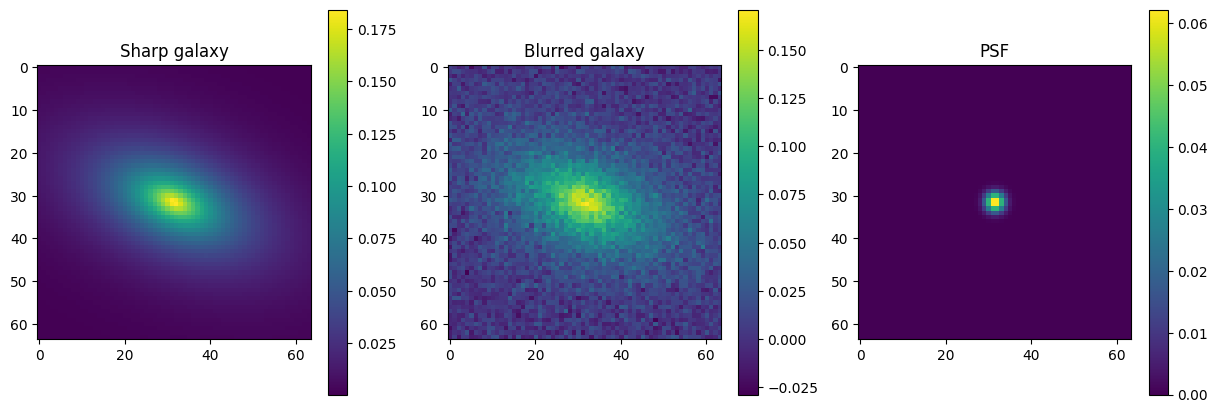

In [4]:
npix = 64 # number of pixels per axis
scale = 0.2 # pixel scale in arcseconds/pixel

# Draw the sharp galaxy
gal_sharp_image = gal.drawImage(nx=npix, ny=npix, scale=scale)

# Draw the blurred galaxy
gal_blurred_image = gal_blurred.drawImage(nx=npix, ny=npix, scale=scale)
gal_blurred_image.addNoise(noise) # add noise

# Draw the PSF only for visualization purposes
psf_image = psf.drawImage(nx=npix, ny=npix, scale=scale)

# Plot the images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
im = ax[0].imshow(gal_sharp_image.array, cmap='viridis')
ax[0].set_title('Sharp galaxy')
plt.colorbar(im, ax=ax[0])
im = ax[1].imshow(gal_blurred_image.array, cmap='viridis')
ax[1].set_title('Blurred galaxy')
plt.colorbar(im, ax=ax[1])
im = ax[2].imshow(psf_image.array, cmap='viridis')
ax[2].set_title('PSF')
plt.colorbar(im, ax=ax[2])
plt.show()

## 3. Modelling and solving the inverse problem with CUQIpy

Now that we have created our simulated galaxy image, the next is to use CUQIpy to define our convolution forward operator, $A$, and use this to construct a forward model. We also construct a cuqi array to store our observed image to be used in setting up the posterior distribution, and a cuqi array to store the true image so it can be plotted for comparison again later.

In [5]:
# We use Deconvolution2D testproblem to get our PSF convolution operator
A, _, _ = cuqi.testproblem.Deconvolution2D(
    dim=npix, # number of pixels per axis
    PSF=psf_image.array, # call array to get the numpy array
    noise_std=sigma, # noise standard deviation
    phantom=gal_sharp_image.array, # call array to get the numpy array
    BC='zero'
).get_components()

# Specify the geometry of the domain (and range in this case)
geom = cuqi.geometry.Image2D(im_shape=(npix, npix), visual_only=False)

# Construct forward model
model = cuqi.model.Model(A, domain_geometry=geom, range_geometry=geom)

# Create cuqi arrays of the observed and true images
observed = cuqi.array.CUQIarray(gal_blurred_image.array.flatten(), geometry=geom)
true = cuqi.array.CUQIarray(gal_sharp_image.array.flatten(), geometry=geom)

Next we specify our prior and likelihood. We use Gaussian Markov random field to ensure smooth prior as our image does not have sharp discontinuities.

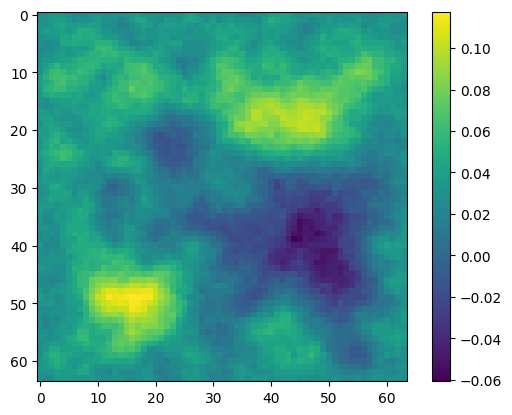

In [6]:
# Prior
x = cuqi.distribution.GMRF(
    mean=np.zeros(gal_sharp_image.array.size)+0.03,
    prec=10000, # need to use high precision to get a good result
    geometry=geom,
    order=2
)

# Likelihood
y = cuqi.distribution.Gaussian(mean=A@x, cov=sigma**2, geometry=geom)

# Plot a sample of the prior to illustrate GMRF smoothing effect
im = x.sample().plot(cmap='viridis')[0]
plt.colorbar(im)

Finally, we construct a joint distribution for our priors `x` and likelihood `y`. We then provide the observed image and sample the posterior using the LinearRTO sampler.

In [7]:
# Now we construct our Bayesian inverse problem 
joint_distribution = cuqi.distribution.JointDistribution(y, x)
posterior = joint_distribution(y=observed)

# Define the sample we want to use, LinearRTO appears to work well
# but need to test further to identify optimal sampler
sampler = cuqi.sampler.LinearRTO(posterior)

# Run the sampler
sampler.sample(500)
samples = sampler.get_samples()

Sample: 100%|██████████| 500/500 [00:29<00:00, 16.76it/s, acc rate: 100.00%]


We plot the results of the sampling below

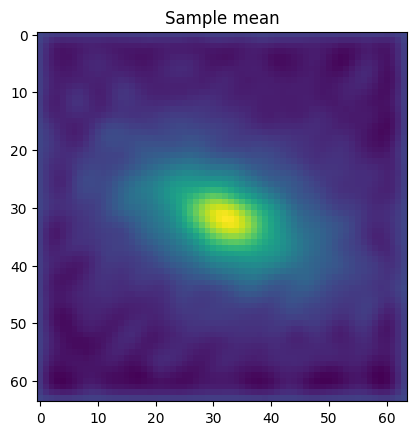

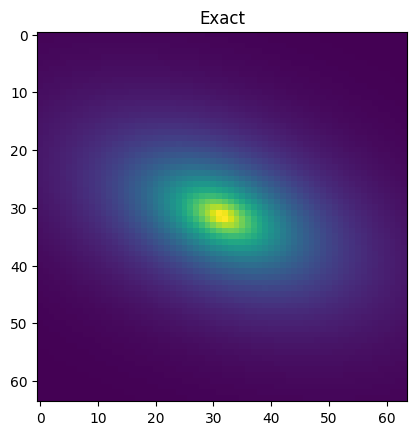

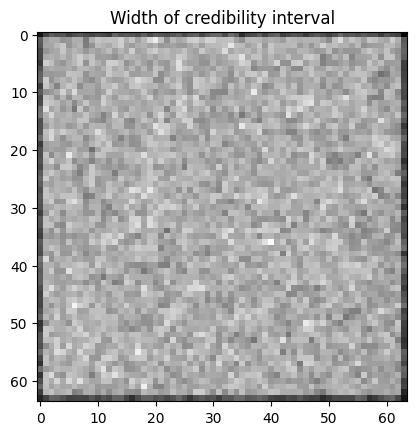

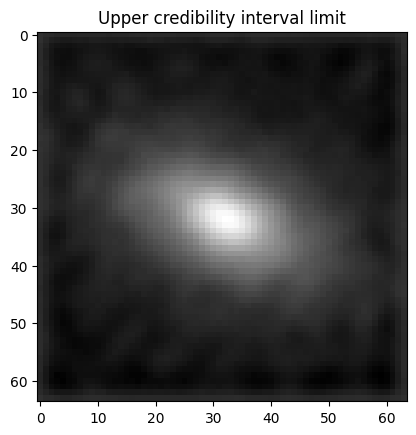

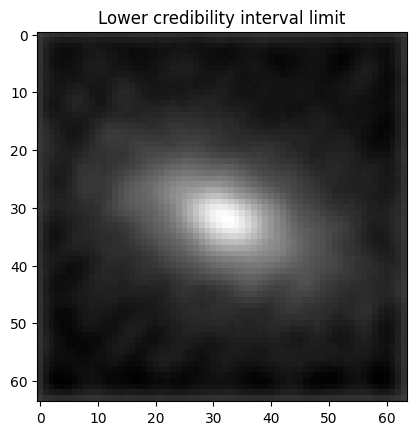

In [8]:
samples.plot_ci(exact=true, cmap='viridis'); # suppress matplotlib printing axes

## 4. Testing shear measurement using Galsim

As mentioned at the start of this notebook, in weak lensing, we wish to measure galaxy shears and then look for correlations in these shears to understand how matter is distributed on large scales. It is important that our shear estimates are biased as little as possible, as any bias can affect what we infer about the matter distribution.

To test how well CUQIpy deconvolution has performed, we will carry out shear estimates on the true, observed, and deconvolved images and compare the results to quantify any biases.

In [9]:
# Measure the moments of the true image to see the input shear parameters
true_moments = galsim.hsm.FindAdaptiveMom(gal_sharp_image)
true_g1 = true_moments.observed_shape.g1
true_g2 = true_moments.observed_shape.g2

# Measure the moments of the observed image to see the effect of the PSF and noise
observed_moments = galsim.hsm.FindAdaptiveMom(gal_blurred_image)
observed_g1 = observed_moments.observed_shape.g1
observed_g2 = observed_moments.observed_shape.g2

# Convert mean to galsim image to use the hsm module for measuring moments
gal_deconv_cuqi = galsim.Image(samples.mean().reshape(npix, npix), scale=scale)

# Measure the moments of the deconvolved image to see how well we recover the input shear parameters
cuqi_moments = galsim.hsm.FindAdaptiveMom(gal_deconv_cuqi)
cuqi_g1 = cuqi_moments.observed_shape.g1
cuqi_g2 = cuqi_moments.observed_shape.g2

# Print the results
print((f"Input shear parameters: g1={g1:.3f}, g2={g2:.3f}"))
print("-----------------------------------"*2)
print(f"Measured from true image: g1={true_g1:.3f}, g2={true_g2:.3f}, bias={g1-true_g1:.3f}, {g2-true_g2:.3f}")
print("-----------------------------------"*2)
print(f"Measured from observed image: g1={observed_g1:.3f}, g2={observed_g2:.3f}, bias={g1-observed_g1:.3f}, {g2-observed_g2:.3f}")
print("-----------------------------------"*2)
print(f"Measured from deconvolved image: g1={cuqi_g1:.3f}, g2={cuqi_g2:.3f}, bias={g1-cuqi_g1:.3f}, {g2-cuqi_g2:.3f}")


Input shear parameters: g1=0.200, g2=0.200
----------------------------------------------------------------------
Measured from true image: g1=0.189, g2=0.196, bias=0.011, 0.004
----------------------------------------------------------------------
Measured from observed image: g1=0.179, g2=0.190, bias=0.021, 0.010
----------------------------------------------------------------------
Measured from deconvolved image: g1=0.188, g2=0.198, bias=0.012, 0.002


 Although the recovery is not perfect, we can see it is less biased than in the case where no denoising or deconvolution took place. It's worth noting that this is an extremely ill-posed problem. As can been seen in the true image, the galaxies we observed in weak lensing are often poorly resolved blobs, even before PSF and noise come into play! 
 
 The important thing CUQIpy gives us here is the credibility interval, as this allows us to propagate uncertaintes forward into our shear measurements. It would be interesting to try and optimise this further using different priors and samplers, but we leave that to future work!